# Empirical Analysis of Algorithms

This example shows how to perform an empirical analysis of an algorithm by measuring its execution time for different input sizes.

**Steps of empirical analysis**

1. Implement the algorithm.
2. Measure its execution time.
3. Run it with different input sizes.
4. Record the measured times.
5. Plot Time vs. Input size using a graph.


## 1) Iterative Solution

Implement a function that calculates the sum of the first N natural numbers using an iterative algorithm.


In [26]:
import time
import pandas as pd
import matplotlib.pyplot as plt


In [27]:
def sum_n(n):
    total = 0
    for i in range(1, n + 1):
        total += i
    return total


Now we measure the execution time for different input sizes.


In [28]:
measurements = []

for i in range(1, 8):

    n = 10**i

    start = time.time()
    result = sum_n(n)
    end = time.time()

    elapsed = end - start

    measurements.append([n, elapsed])

df = pd.DataFrame(measurements, columns=["N", "Time (s)"])
df


,N,Time (s)
0,10,0.000006
1,100,0.000011
2,1000,0.000118
3,10000,0.003939
4,100000,0.020082
5,1000000,0.120029
6,10000000,1.274359


The next step is to obtain a graphical representation that allows us to study how the execution time behaves as a function of the input size.


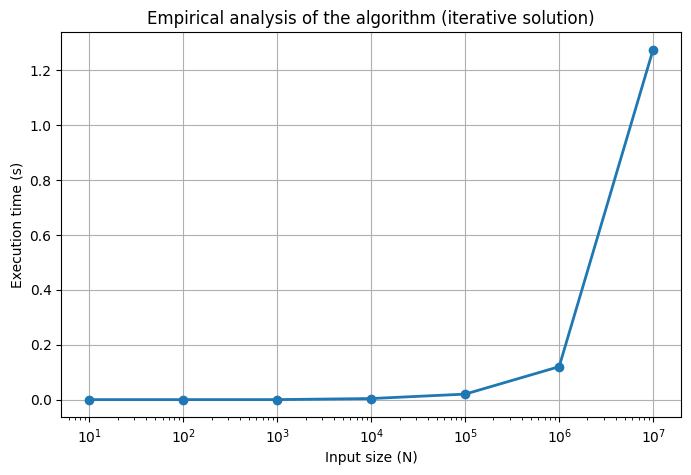

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    df["N"],
    df["Time (s)"],
    marker="o",
    linewidth=2
)

plt.xscale("log")  # Log scale on the X axis ensures both small and large inputs (N=10 to 10M) are easily readable.


plt.title("Empirical analysis of the algorithm (iterative solution)")
plt.xlabel("Input size (N)")
plt.ylabel("Execution time (s)")
plt.grid(True)

plt.show()


## 2) Solution Based on Gauss's Sum


          N      Time (s)
0        10  2.384186e-06
1       100  1.430511e-06
2      1000  1.192093e-06
3     10000  4.768372e-07
4    100000  1.430511e-06
5   1000000  7.152557e-07
6  10000000  4.768372e-07


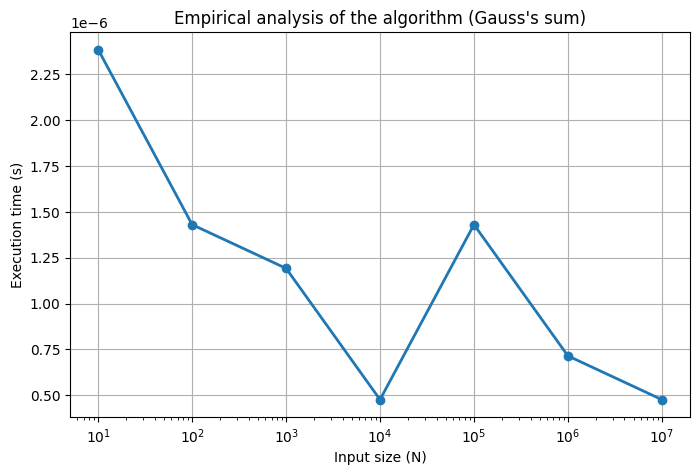

In [30]:
def gauss_sum(n):
    return n * (n + 1) // 2

# Measurement of execution time (O(1))
measurements = []

for i in range(1, 8):

    n = 10**i

    start = time.time()
    result = gauss_sum(n)
    end = time.time()

    elapsed = end - start

    measurements.append([n, elapsed])

df_gauss = pd.DataFrame(measurements, columns=["N", "Time (s)"])
print(df_gauss)

# Graphical representation

plt.figure(figsize=(8,5))

plt.plot(
    df_gauss["N"],
    df_gauss["Time (s)"],
    marker="o",
    linewidth=2
)

plt.xscale("log")  # Log scale on the X axis ensures both small and large inputs (N=10 to 10M) are easily readable.

plt.title("Empirical analysis of the algorithm (Gauss's sum)")
plt.xlabel("Input size (N)")
plt.ylabel("Execution time (s)")
plt.grid(True)

plt.show()


## Comparison: iterative vs. Gauss

A logarithmic scale is used on the Y axis to make it easier to compare algorithms with very different execution times.


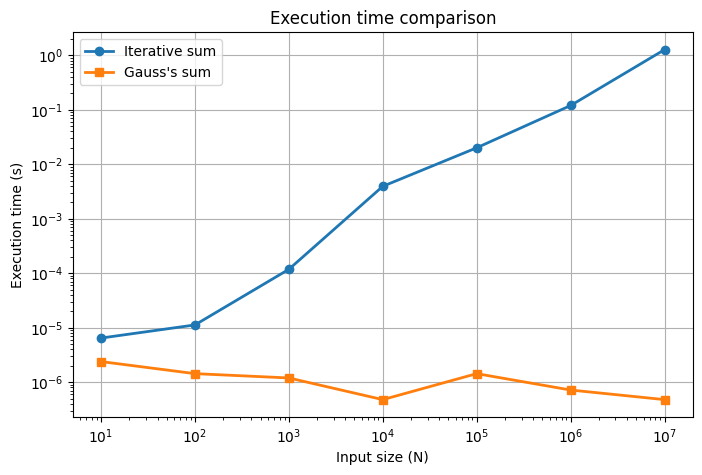

In [31]:
plt.figure(figsize=(8,5))

plt.plot(df["N"],
         df["Time (s)"],
         marker="o",
         linewidth=2,
         label="Iterative sum")

plt.plot(df_gauss["N"],
         df_gauss["Time (s)"],
         marker="s",
         linewidth=2,
         label="Gauss's sum")


plt.yscale("log")  # Use a logarithmic scale on the Y axis to make it easier to compare algorithms with very different execution times.
plt.xscale("log")  # Log scale on the X axis ensures both small and large inputs (N=10 to 10M) are easily readable.

plt.title("Execution time comparison")
plt.xlabel("Input size (N)")
plt.ylabel("Execution time (s)")
plt.grid(True)
plt.legend()

plt.show()
